In [ ]:
!pip install -q \
ultralytics \
supervision \
roboflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 101.2 MB/s eta 0:00:00


In [ ]:
import cv2
from ultralytics import YOLO
import supervision as sv

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os

VIDEO_PATH = "highway427.mp4"

# Verifica se o arquivo existe
if os.path.exists(VIDEO_PATH):
    print(f"✓ Arquivo encontrado: {VIDEO_PATH}")
else:
    print(f"✗ Arquivo NÃO encontrado: {VIDEO_PATH}")
    print(f"\nArquivos na pasta atual:")
    print([f for f in os.listdir('.') if f.endswith('.mp4')])

✓ Arquivo encontrado: highway427.mp4


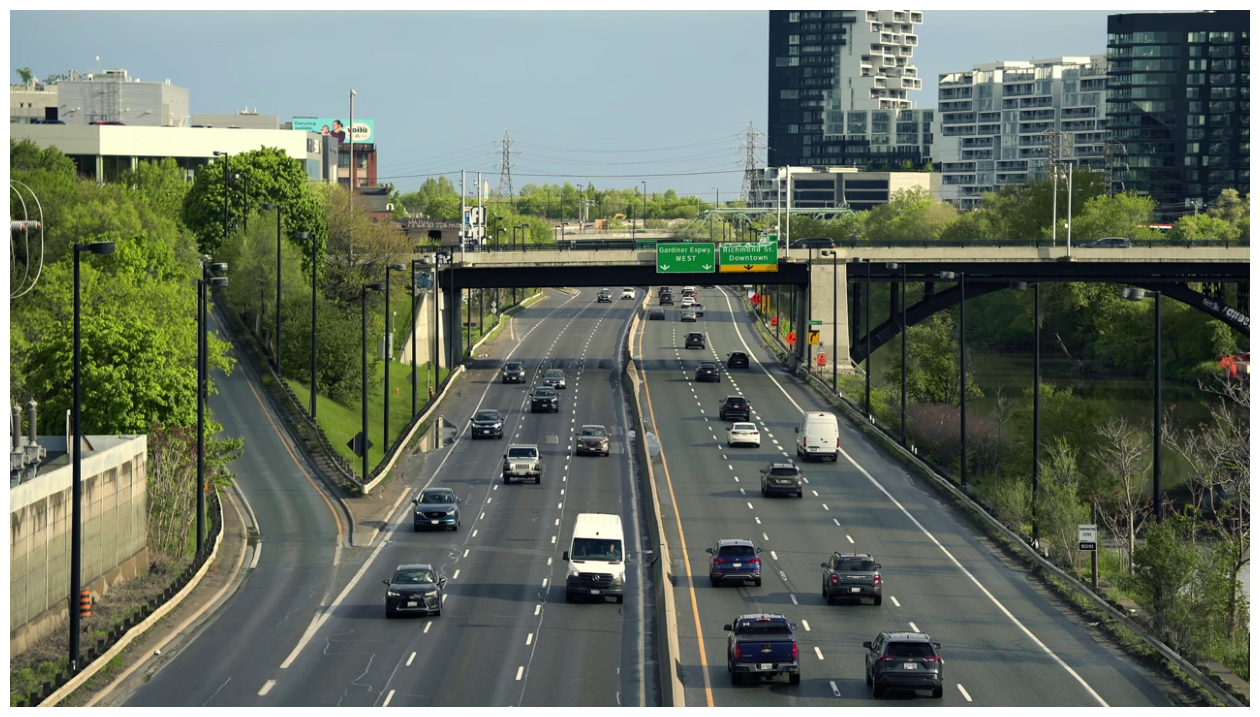

In [ ]:

# extract video frame (get image from the video)
generator = sv.get_video_frames_generator(VIDEO_PATH)
iterator = iter(generator)
frame = next(iterator)
sv.plot_image(frame,(16,16))

In [ ]:
model = YOLO("yolov8m.pt")

32


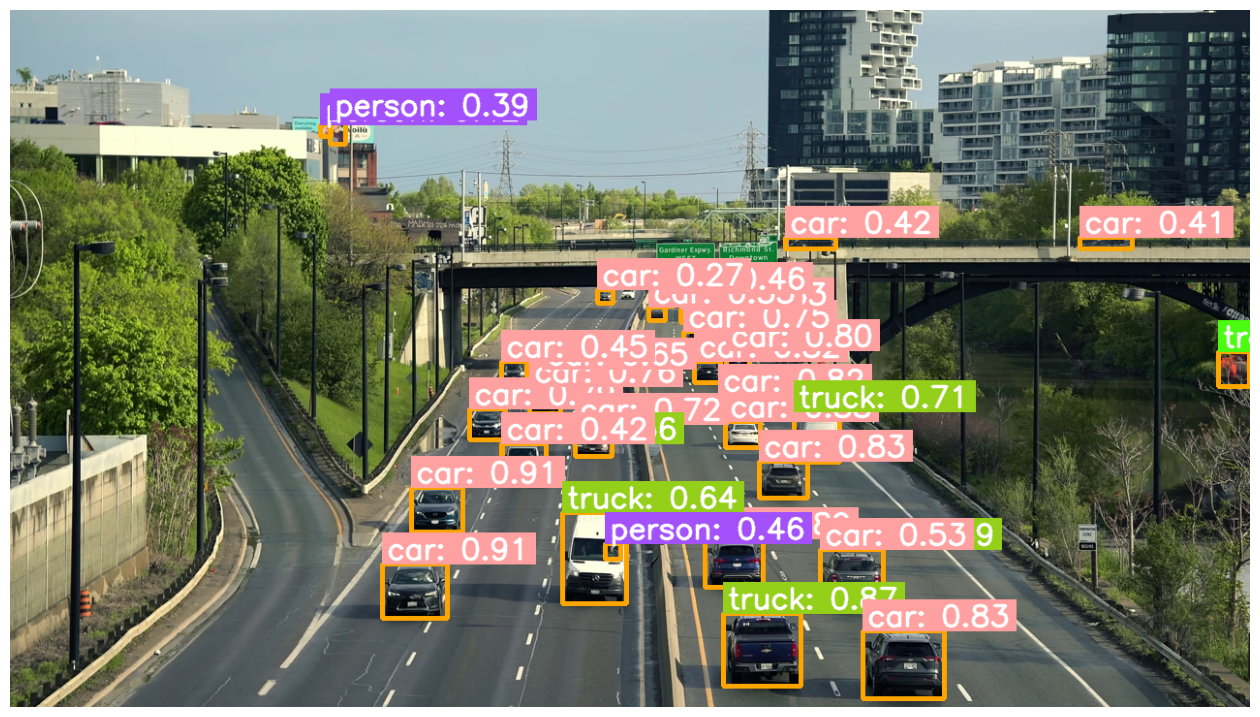

In [ ]:
results = model(frame, imgsz=2304, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results)
detections = detections[detections.confidence >= 0.25]

print(len(detections))

labels = [
    f"{results.names[class_id]}: {confidence:.2f}"
    for class_id, confidence in zip(detections.class_id, detections.confidence)
]

# Annotator para caixas (sem text_thickness)
box_annotator = sv.BoxAnnotator(
    thickness=4,
    color=sv.Color.from_hex("#FFA500")
)

# Annotator para labels (com text_thickness)
label_annotator = sv.LabelAnnotator(
    text_scale=1,
    text_thickness=2,
    text_padding=5,
    text_color=sv.Color.WHITE,
    text_position=sv.Position.TOP_LEFT
)

# Anotar o frame (duas etapas)
frame = box_annotator.annotate(scene=frame, detections=detections)
frame = label_annotator.annotate(scene=frame, detections=detections, labels=labels)

sv.plot_image(frame, (16, 16))

Zona 0: 18 carros


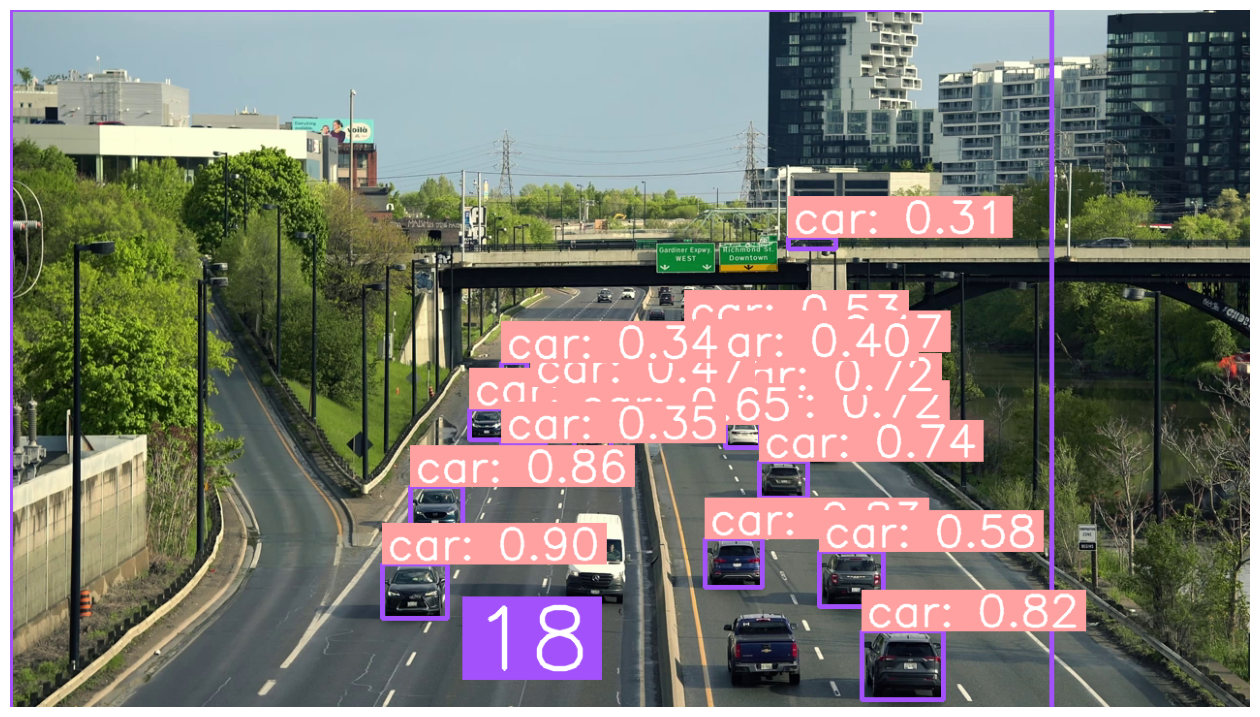

In [ ]:
generator = sv.get_video_frames_generator(VIDEO_PATH)
iterator = iter(generator)
frame = next(iterator)
image = frame
height, width, channels = image.shape

polygons = [
    np.array([
        [0, 0],
        [1080 - 5, 0],
        [1080 - 5, 1300 - 5],
        [0, 1300 - 5]
    ], np.int32)

]

colors = sv.ColorPalette.DEFAULT

# Zonas
zones = [
    sv.PolygonZone(polygon=polygon)
    for polygon in polygons
]

# Zone annotators com configuração explícita
zone_annotators = [
    sv.PolygonZoneAnnotator(
        zone=zone,
        color=colors.by_idx(index),
        thickness=4,
        text_color=sv.Color.WHITE,
        text_scale=3,
        text_thickness=3,
        text_padding=10
    )
    for index, zone in enumerate(zones)
]

# Box annotators
box_annotators = [
    sv.BoxAnnotator(
        color=colors.by_idx(index),
        thickness=4
    )
    for index in range(len(polygons))
]

# Label annotator para confiança
label_annotator = sv.LabelAnnotator(
    text_scale=1.5,
    text_thickness=2,
    text_padding=5,
    text_position=sv.Position.TOP_LEFT
)

# Detecções
results = model(frame, imgsz=1280, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results)
detections = detections[(detections.class_id == 2) & (detections.confidence >= 0.25)]

# Anotar cada zona
for index, (zone, zone_annotator, box_annotator) in enumerate(zip(zones, zone_annotators, box_annotators)):
    mask = zone.trigger(detections=detections)
    detections_filtered = detections[mask]

    print(f"Zona {index}: {len(detections_filtered)} carros")

    # Anotar zona PRIMEIRO (isso deve mostrar o contador)
    frame = zone_annotator.annotate(scene=frame)

# Depois anotar todos os boxes e labels
for index, (zone, box_annotator) in enumerate(zip(zones, box_annotators)):
    mask = zone.trigger(detections=detections)
    detections_filtered = detections[mask]

    labels = [
        f"{results.names[class_id]}: {confidence:.2f}"
        for class_id, confidence in zip(detections_filtered.class_id, detections_filtered.confidence)
    ]

    frame = box_annotator.annotate(scene=frame, detections=detections_filtered)
    frame = label_annotator.annotate(scene=frame, detections=detections_filtered, labels=labels)

sv.plot_image(frame, (16, 16))

16 carros


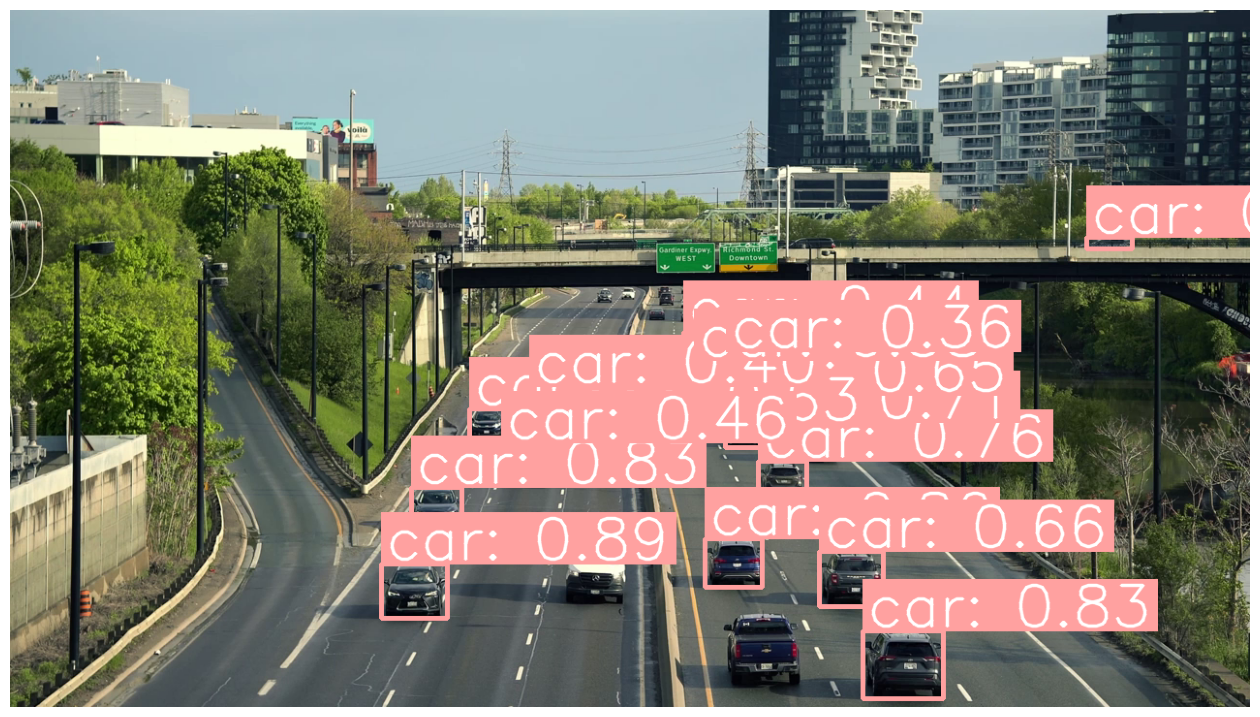

In [ ]:
import numpy as np

# Resto do código
generator = sv.get_video_frames_generator(VIDEO_PATH)
iterator = iter(generator)
frame = next(iterator)
height, width, channels = frame.shape

box_annotator = sv.BoxAnnotator(thickness=4)

label_annotator = sv.LabelAnnotator(
    text_scale=2,
    text_thickness=2,
    text_padding=5
)

# Detecções
results = model(frame, imgsz=1248)[0]
detections = sv.Detections.from_ultralytics(results)

# Filtrar APENAS por classe e confiança (sem zona, pega tudo)
detections = detections[
    (detections.class_id == 2) &
    (detections.confidence >= 0.25)
]

# Labels
labels = [
    f"{results.names[class_id]}: {conf:.2f}"
    for class_id, conf in zip(detections.class_id, detections.confidence)
]

# Anotar frame (sem zona)
frame = box_annotator.annotate(scene=frame, detections=detections)
frame = label_annotator.annotate(scene=frame, detections=detections, labels=labels)

for index, (zone, zone_annotator, box_annotator) in enumerate(zip(zones, zone_annotators, box_annotators)):
    mask = zone.trigger(detections=detections)
    detections_filtered = detections[mask]

    print(f"{len(detections)} carros")

sv.plot_image(frame, (16, 16))

In [ ]:
def process_frame(frame: np.ndarray, index: int) -> np.ndarray:
    # Detecções
    results = model(frame, imgsz=1280, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = detections[(detections.class_id == 2) & (detections.confidence >= 0.40)]

    # Anotar cada zona
    for index_zone, (zone, zone_annotator, box_annotator) in enumerate(zip(zones, zone_annotators, box_annotators)):
        mask = zone.trigger(detections=detections)
        detections_filtered = detections[mask]

        # Labels com confiança
        labels = [
            f"{results.names[class_id]}: {confidence:.2f}"
            for class_id, confidence in zip(detections_filtered.class_id, detections_filtered.confidence)
        ]

        # Anotar: zona -> boxes -> labels
        frame = zone_annotator.annotate(scene=frame)
        frame = box_annotator.annotate(scene=frame, detections=detections_filtered)  # SEM skip_label
        frame = label_annotator.annotate(scene=frame, detections=detections_filtered, labels=labels)

    return frame

In [ ]:
sv.process_video(source_path=VIDEO_PATH, target_path="result.mp4", callback=process_frame)